In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
 
from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.linear_model       import LinearRegression
from sklearn.tree               import DecisionTreeRegressor
from sklearn.ensemble           import RandomForestRegressor
from sklearn.metrics            import r2_score, mean_absolute_error, mean_squared_error
 
os.makedirs("outputs", exist_ok=True)
sns.set_style("whitegrid")
 
print("=" * 55)
print("STEP 3 : Model Training & Evaluation")
print("=" * 55)

STEP 3 : Model Training & Evaluation


In [6]:
df = pd.read_csv("data/cleaned_data.csv")
print(f"\n✅ Loaded cleaned data  →  {df.shape[0]} rows")


✅ Loaded cleaned data  →  21235 rows


In [7]:
df["Log_Arrival"] = np.log1p(df["Arrival"])
 
FEATURES = ["District", "Taluk", "Market", "Commodity", "Unit", "Month_Num"]
TARGET   = "Log_Arrival"
 
X = df[FEATURES]
y = df[TARGET]
 
print(f"✅ Features used    : {FEATURES}")
print(f"✅ Target           : {TARGET}  (we'll convert back with exp for display)")

✅ Features used    : ['District', 'Taluk', 'Market', 'Commodity', 'Unit', 'Month_Num']
✅ Target           : Log_Arrival  (we'll convert back with exp for display)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Train size : {len(X_train):,} rows")
print(f"✅ Test size  : {len(X_test):,}  rows")


✅ Train size : 16,988 rows
✅ Test size  : 4,247  rows


In [9]:
cat_features = ["District", "Taluk", "Market", "Commodity", "Unit"]
num_features = ["Month_Num"]
 
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ("num", "passthrough", num_features),
])

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree"    : DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest"    : RandomForestRegressor(n_estimators=200, max_depth=12,
                                               random_state=42, n_jobs=-1),
}

In [11]:
results      = []
predictions  = {}
pipelines    = {}
 
print("\n📈 Training models...\n")
 
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model"        , model),
    ])
    pipe.fit(X_train, y_train)
 
    y_pred_log = pipe.predict(X_test)


📈 Training models...



In [12]:
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
 
    r2   = r2_score(y_test, y_pred_log)          # R² on log scale
    mae  = mean_absolute_error(y_test_real, y_pred_real)   # MAE in Quintals
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
 
    results.append({"Model": name, "R2": round(r2, 4),
                    "MAE": round(mae, 2), "RMSE": round(rmse, 2)})
    predictions[name] = (y_pred_real, y_test_real.values)
    pipelines[name]   = pipe
 
    print(f"  {name:20s}  R²={r2:.4f}  MAE={mae:>10,.2f}  RMSE={rmse:>10,.2f}")

  Random Forest         R²=0.3448  MAE=    988.38  RMSE=  1,902.53


In [13]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
best_name  = results_df.iloc[0]["Model"]
best_pipe  = pipelines[best_name]
 
results_df.to_csv("outputs/model_comparison.csv", index=False)
joblib.dump(best_pipe, "outputs/best_model.pkl")
 
print(f"\n🏆 Best Model : {best_name}")
print(f"\n📋 Full Comparison:\n")
print(results_df.to_string(index=False))


🏆 Best Model : Random Forest

📋 Full Comparison:

        Model     R2    MAE    RMSE
Random Forest 0.3448 988.38 1902.53


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#2563eb", "#16a34a", "#dc2626"]
 
for ax, metric, color in zip(axes, ["R2", "MAE", "RMSE"], colors):
    bars = ax.bar(results_df["Model"], results_df[metric], color=color, width=0.5)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
    ax.bar_label(bars, fmt="{:.2f}", padding=4, fontsize=9)
 
plt.suptitle("Model Comparison — Karnataka APMC Sales Prediction",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n✅ Saved  →  outputs/model_comparison.png")


✅ Saved  →  outputs/model_comparison.png


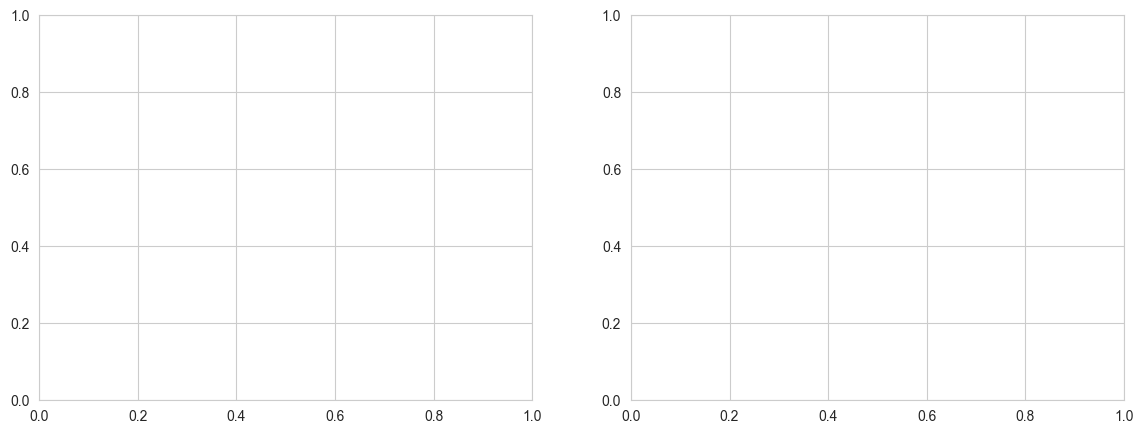

In [15]:
y_pred_best, y_test_vals = predictions[best_name]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [16]:
# Scatter plot
sample_idx = np.random.choice(len(y_test_vals), size=min(500, len(y_test_vals)), replace=False)
axes[0].scatter(y_test_vals[sample_idx], y_pred_best[sample_idx],
                alpha=0.5, color="#2563eb", edgecolor="white", s=40)
max_val = max(y_test_vals[sample_idx].max(), y_pred_best[sample_idx].max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual Arrival (Quintals)", fontsize=11)
axes[0].set_ylabel("Predicted Arrival (Quintals)", fontsize=11)
axes[0].set_title(f"Actual vs Predicted — {best_name}", fontsize=12, fontweight="bold")
axes[0].legend()
 
# Residual plot
residuals = y_test_vals - y_pred_best
axes[1].scatter(y_pred_best[sample_idx], residuals[sample_idx],
                alpha=0.5, color="#f97316", edgecolor="white", s=40)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted Arrival", fontsize=11)
axes[1].set_ylabel("Residual (Actual − Predicted)", fontsize=11)
axes[1].set_title("Residual Plot", fontsize=12, fontweight="bold")
 
plt.tight_layout()
plt.savefig("outputs/actual_vs_predicted.png", dpi=150)
plt.close()
print("✅ Saved  →  outputs/actual_vs_predicted.png")

✅ Saved  →  outputs/actual_vs_predicted.png


In [17]:
if best_name in ("Decision Tree", "Random Forest"):
    ohe         = best_pipe.named_steps["preprocessor"].named_transformers_["cat"]
    cat_names   = list(ohe.get_feature_names_out(cat_features))
    all_names   = cat_names + num_features
    importances = best_pipe.named_steps["model"].feature_importances_
 
    imp_df = pd.DataFrame({"Feature": all_names, "Importance": importances})
 
    # Group by original column (sum OHE sub-features)
    def get_original(feat_name):
        for col in cat_features:
            if feat_name.startswith(f"cat__{col}_") or feat_name == col:
                return col
        return feat_name
 
    imp_df["Original"] = imp_df["Feature"].apply(get_original)
    grouped = imp_df.groupby("Original")["Importance"].sum().sort_values(ascending=True)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(grouped.index, grouped.values, color="#7c3aed")
    ax.set_xlabel("Total Feature Importance", fontsize=11)
    ax.set_title(f"Feature Importance — {best_name}", fontsize=13, fontweight="bold")
    ax.bar_label(bars, fmt="{:.3f}", padding=4, fontsize=9)
    plt.tight_layout()
    plt.savefig("outputs/feature_importance.png", dpi=150)
    plt.close()
    print("✅ Saved  →  outputs/feature_importance.png")
 
print(f"\n✅ Best model saved  →  outputs/best_model.pkl")
print("\n▶  Next: run   python step4_predict.py")

✅ Saved  →  outputs/feature_importance.png

✅ Best model saved  →  outputs/best_model.pkl

▶  Next: run   python step4_predict.py
